# 03 · Return levels and return periods

Engineers and planners rarely want $\mu, \sigma, \xi$ directly — they want the
**return level** $z_T$: the value exceeded on average once every $T$ years. It is
just a high quantile of the GEV,

$$ z_T = F^{-1}\!\left(1 - \tfrac{1}{T}\right). $$

`xtremax` gives this two ways: the distribution method `.return_level(T)` and the
pure primitive `gev_return_level(T, loc, scale, shape)`. Because we have a
*posterior* over the parameters, we get a posterior over the whole return-level
curve — i.e. honest uncertainty bands.

In [1]:
import sys, pathlib
_p = pathlib.Path.cwd().resolve()
while not (_p / "src" / "spatial_extremes").exists():
    if _p == _p.parent:
        raise RuntimeError("Run from inside the spatial_extremes project")
    _p = _p.parent
if str(_p / "src") not in sys.path:
    sys.path.insert(0, str(_p / "src"))

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_return_level
from spatial_extremes import data

maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
order = np.isfinite(maxima).sum(1) + np.nan_to_num(np.nanmean(maxima, 1)) / 1e3
sidx = int(np.argmax(order))
m_ = np.isfinite(maxima[sidx])
y = jnp.asarray(maxima[sidx][m_])
y_mean, y_std = float(jnp.mean(y)), float(jnp.std(y))   # constants, not tracers

def gev_model(obs):
    mu = numpyro.sample("mu", ndist.Normal(y_mean, 5.0))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(y_std))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample("obs", GEV(loc=mu, scale=sigma, concentration=xi), obs=obs)

mcmc = MCMC(NUTS(gev_model, target_accept_prob=0.95, init_strategy=init_to_median),
            num_warmup=800, num_samples=800, num_chains=1, progress_bar=False)
mcmc.run(jr.PRNGKey(0), y)
post = mcmc.get_samples()
print("source:", "REAL" if is_real else "SYNTHETIC", "| station", sidx)

source: REAL | station 12


In [4]:
periods = jnp.array([2., 5., 10., 20., 50., 100., 200., 500.])

# posterior return-level curve: vmap over posterior draws
def rl(mu, sigma, xi):
    return GEV(loc=mu, scale=sigma, concentration=xi).return_level(periods)

rls = jax.vmap(rl)(post["mu"], post["sigma"], post["xi"])  # (n_draws, n_periods)
med = np.median(rls, 0)
lo, hi = np.quantile(rls, 0.025, 0), np.quantile(rls, 0.975, 0)

# sanity check: the pure primitive agrees with the distribution method
prim = gev_return_level(100., float(np.median(post["mu"])),
                        float(np.median(post["sigma"])), float(np.median(post["xi"])))
print(f"100-yr return level (median): {med[5]:.1f} °C  "
      f"(primitive check: {float(prim):.1f} °C)")

100-yr return level (median): 43.4 °C  (primitive check: 43.4 °C)


Empirical return levels (Gringorten plotting positions) let us eyeball the fit:

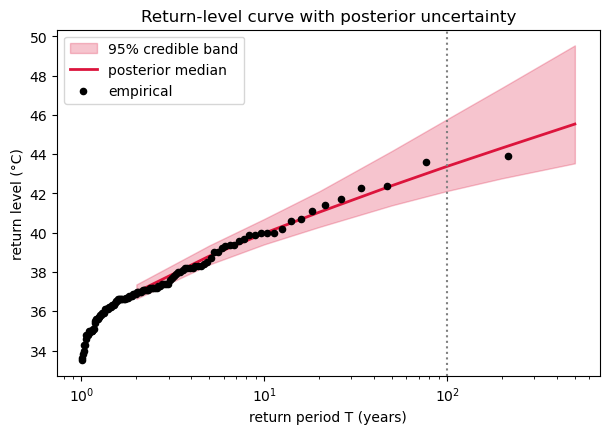

In [5]:
ys = np.sort(np.asarray(y))
n = ys.size
emp_p = (np.arange(1, n + 1) - 0.44) / (n + 0.12)   # Gringorten
emp_T = 1.0 / (1.0 - emp_p)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.fill_between(np.asarray(periods), lo, hi, alpha=0.25, color="crimson",
                label="95% credible band")
ax.plot(np.asarray(periods), med, color="crimson", lw=2, label="posterior median")
ax.scatter(emp_T, ys, color="k", s=20, zorder=5, label="empirical")
ax.axvline(100, ls=":", color="0.5")
ax.set_xscale("log")
ax.set_xlabel("return period T (years)")
ax.set_ylabel("return level (°C)")
ax.set_title("Return-level curve with posterior uncertainty")
ax.legend()
plt.show()

**Next:** do this for *every* station and map the parameters — exposing why we need to pool information across space.